# VT - Vanguard Total World Stock ETF

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ruptures import Binseg
from pandas.plotting import autocorrelation_plot

%matplotlib inline

In [75]:
file_path = "VT_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

In [76]:
categorized_df.head()

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2008-07-01,42.449,42.857,41.247,42.423,63725,"(41.86, 42.647]","(42.825, 43.611]","(40.814, 41.604]","(41.785, 42.578]","(52136.886000000006, 68907.043]"
1,2008-07-02,42.802,42.931,41.799,41.799,86429,"(42.647, 43.434]","(42.825, 43.611]","(41.604, 42.395]","(41.785, 42.578]","(84580.086, 100253.129]"
2,2008-07-07,42.145,42.163,41.300,41.827,64235,"(41.86, 42.647]","(42.038, 42.825]","(40.814, 41.604]","(41.785, 42.578]","(52136.886000000006, 68907.043]"
3,2008-07-08,41.574,41.957,40.758,41.907,62746,"(41.073, 41.86]","(41.251, 42.038]","(40.023, 40.814]","(41.785, 42.578]","(52136.886000000006, 68907.043]"
4,2008-07-23,42.674,42.742,42.285,42.406,54540,"(42.647, 43.434]","(42.038, 42.825]","(41.604, 42.395]","(41.785, 42.578]","(52136.886000000006, 68907.043]"


# Time series analysis

formatting date

In [77]:
# Check the Date column
print(categorized_df['Date'].head(10))

# Convert the Date column to datetime with a specified format
categorized_df['Date'] = pd.to_datetime(categorized_df['Date'], format='%Y-%m-%d', errors='coerce')

# Identify invalid dates
invalid_dates = categorized_df[categorized_df['Date'].isna()]
print("Invalid Dates:")
print(invalid_dates)

# Remove rows with invalid dates
categorized_df = categorized_df.dropna(subset=['Date'])

# Recheck the data information
print(categorized_df.info())
# categorized_df

0    2008-07-01
1    2008-07-02
2    2008-07-07
3    2008-07-08
4    2008-07-23
5    2008-07-28
6    2008-08-01
7    2008-08-14
8    2008-08-25
9    2008-09-04
Name: Date, dtype: object
Invalid Dates:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Volume, Open_category, High_category, Low_category, Close_category, Volume_category]
Index: []
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2124 entries, 0 to 2123
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2124 non-null   datetime64[ns]
 1   Open             2124 non-null   float64       
 2   High             2124 non-null   float64       
 3   Low              2124 non-null   float64       
 4   Close            2124 non-null   float64       
 5   Volume           2124 non-null   int64         
 6   Open_category    2124 non-null   object        
 7   High_category    2124 non-null   object        
 8   Low_ca

#### Trend Analysis

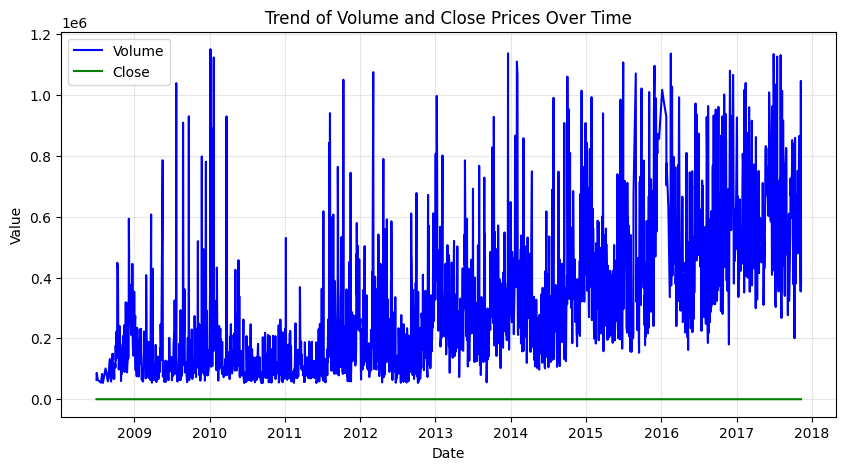

In [78]:
plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Volume'], label='Volume', color='blue')
plt.plot(categorized_df['Date'], categorized_df['Close'], label='Close', color='green')
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Trend of Volume and Close Prices Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Seasonality Analysis

In [79]:
categorized_df['Year'] = categorized_df['Date'].dt.year
categorized_df['Month'] = categorized_df['Date'].dt.month
categorized_df

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category,Year,Month
0,2008-07-01,42.449,42.857,41.2470,42.423,63725,"(41.86, 42.647]","(42.825, 43.611]","(40.814, 41.604]","(41.785, 42.578]","(52136.886000000006, 68907.043]",2008,7
1,2008-07-02,42.802,42.931,41.7990,41.799,86429,"(42.647, 43.434]","(42.825, 43.611]","(41.604, 42.395]","(41.785, 42.578]","(84580.086, 100253.129]",2008,7
2,2008-07-07,42.145,42.163,41.3000,41.827,64235,"(41.86, 42.647]","(42.038, 42.825]","(40.814, 41.604]","(41.785, 42.578]","(52136.886000000006, 68907.043]",2008,7
3,2008-07-08,41.574,41.957,40.7580,41.907,62746,"(41.073, 41.86]","(41.251, 42.038]","(40.023, 40.814]","(41.785, 42.578]","(52136.886000000006, 68907.043]",2008,7
4,2008-07-23,42.674,42.742,42.2850,42.406,54540,"(42.647, 43.434]","(42.038, 42.825]","(41.604, 42.395]","(41.785, 42.578]","(52136.886000000006, 68907.043]",2008,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2119,2017-11-03,72.460,72.510,72.2400,72.510,716487,"(71.763, 72.55]","(71.933, 72.72]","(71.649, 72.44]","(71.917, 72.71]","(711501.8, 727174.843]",2017,11
2120,2017-11-06,72.460,72.720,72.4400,72.700,498806,"(71.763, 72.55]","(71.933, 72.72]","(71.649, 72.44]","(71.917, 72.71]","(492079.2, 507752.243]",2017,11
2121,2017-11-08,72.550,72.720,72.4347,72.710,354305,"(71.763, 72.55]","(71.933, 72.72]","(71.649, 72.44]","(71.917, 72.71]","(351021.814, 366694.857]",2017,11
2122,2017-11-09,72.220,72.340,71.8500,72.310,1046159,"(71.763, 72.55]","(71.933, 72.72]","(71.649, 72.44]","(71.917, 72.71]","(1040635.7, 1056308.743]",2017,11


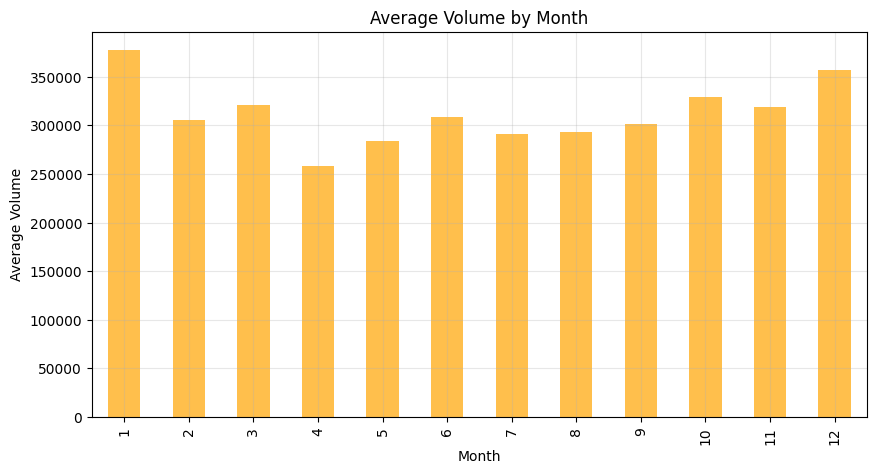

In [80]:
# Calculate the average trading volume for each month
monthly_avg_volume = categorized_df.groupby('Month')['Volume'].mean()

# Plot the monthly volume changes
plt.figure(figsize=(10, 5))
monthly_avg_volume.plot(kind='bar', color='orange', alpha=0.7)
plt.title("Average Volume by Month")
plt.xlabel("Month")
plt.ylabel("Average Volume")
plt.grid(alpha=0.3)
plt.show()

#### Lagged Correlation Analysis

Lagged Correlation:
               Volume  Volume_lag1
Volume       1.000000     0.562158
Volume_lag1  0.562158     1.000000


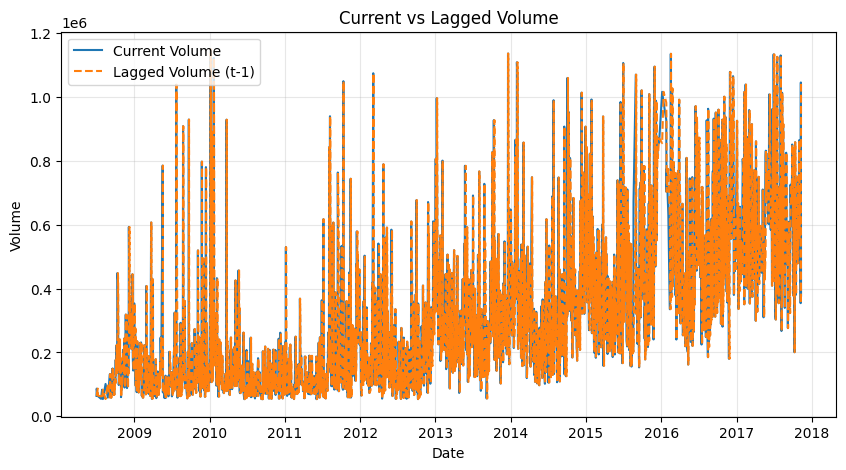

In [81]:
# Create a lagged version of the Volume column (lag)
categorized_df['Volume_lag1'] = categorized_df['Volume'].shift(1)

# Calculate the correlation between the current and lagged Volume
lagged_corr = categorized_df[['Volume', 'Volume_lag1']].corr()
print("Lagged Correlation:")
print(lagged_corr)

# Plot a comparison chart
plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Volume'], label='Current Volume')
plt.plot(categorized_df['Date'], categorized_df['Volume_lag1'], label='Lagged Volume (t-1)', linestyle='--')
plt.xlabel("Date")
plt.ylabel("Volume")
plt.title("Current vs Lagged Volume")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Cumulative Analysis

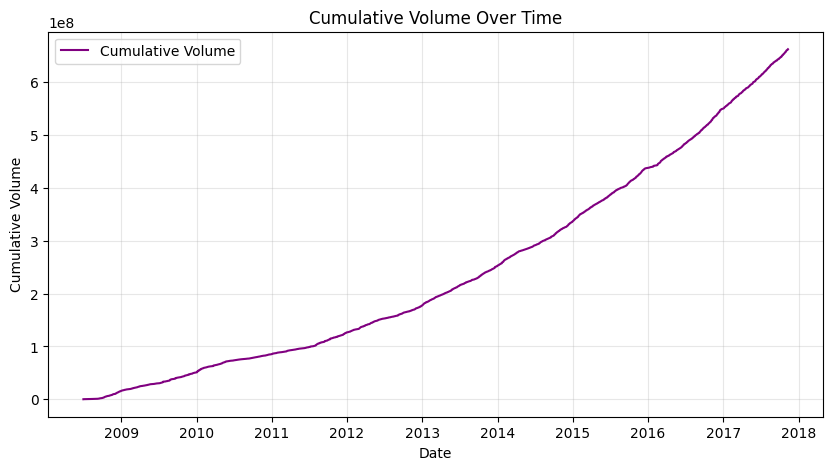

In [82]:
categorized_df['Cumulative_Volume'] = categorized_df['Volume'].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Cumulative_Volume'], color='purple', label='Cumulative Volume')
plt.xlabel("Date")
plt.ylabel("Cumulative Volume")
plt.title("Cumulative Volume Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Moving Average Analysis

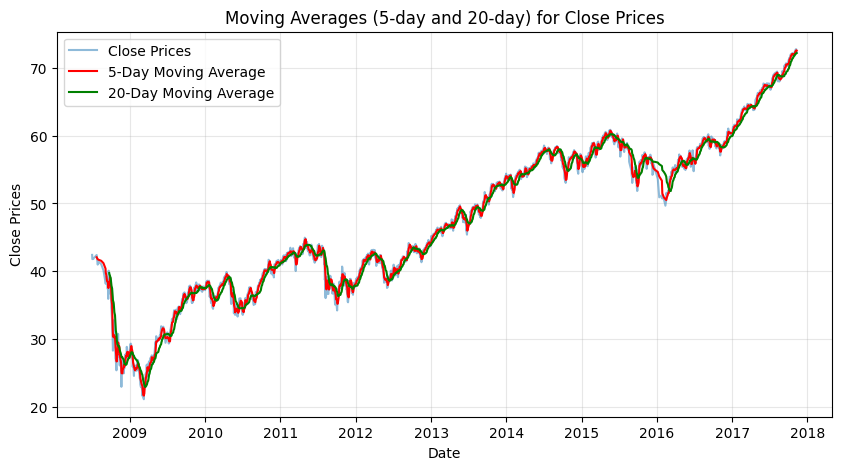

In [83]:
categorized_df['MA_5'] = categorized_df['Close'].rolling(window=5).mean()
categorized_df['MA_20'] = categorized_df['Close'].rolling(window=20).mean()

plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Close'], label='Close Prices', alpha=0.5)
plt.plot(categorized_df['Date'], categorized_df['MA_5'], label='5-Day Moving Average', color='red')
plt.plot(categorized_df['Date'], categorized_df['MA_20'], label='20-Day Moving Average', color='green')
plt.xlabel("Date")
plt.ylabel("Close Prices")
plt.title("Moving Averages (5-day and 20-day) for Close Prices")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Change point detection

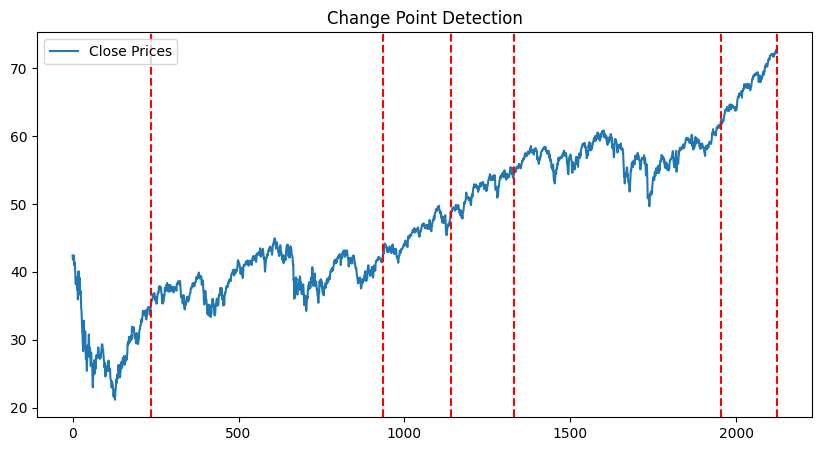

In [84]:
signal = categorized_df['Close'].values
algo = Binseg(model="l2").fit(signal)
change_points = algo.predict(n_bkps=5)

plt.figure(figsize=(10, 5))
plt.plot(signal, label="Close Prices")
for cp in change_points:
    plt.axvline(cp, color='red', linestyle='--')
plt.title("Change Point Detection")
plt.legend()
plt.show()

#### Volatility and Returns Analysis

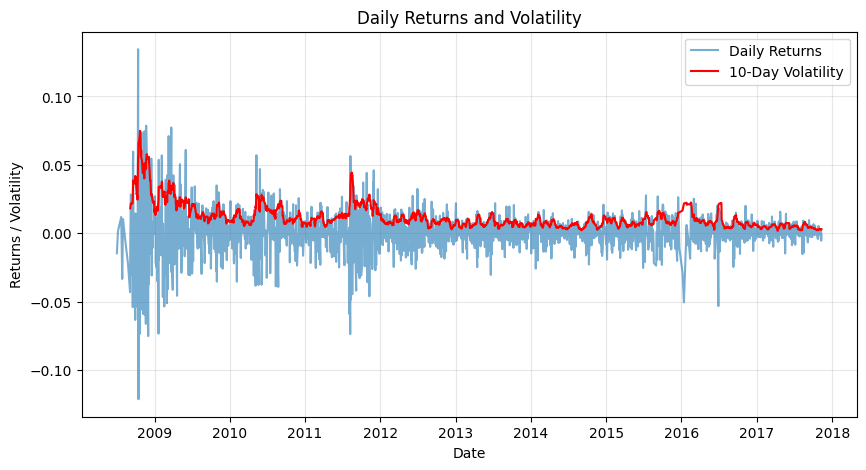

In [85]:
# Calculate daily returns
categorized_df['Daily_Return'] = categorized_df['Close'].pct_change()  # Percentage change for daily returns

# Calculate volatility
volatility = categorized_df['Daily_Return'].rolling(window=10).std()

# Plot daily returns and volatility
plt.figure(figsize=(10, 5))
plt.plot(categorized_df['Date'], categorized_df['Daily_Return'], label='Daily Returns', alpha=0.6)
plt.plot(categorized_df['Date'], volatility, label='10-Day Volatility', color='red')
plt.xlabel("Date")
plt.ylabel("Returns / Volatility")
plt.title("Daily Returns and Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Autocorrelation Analysis

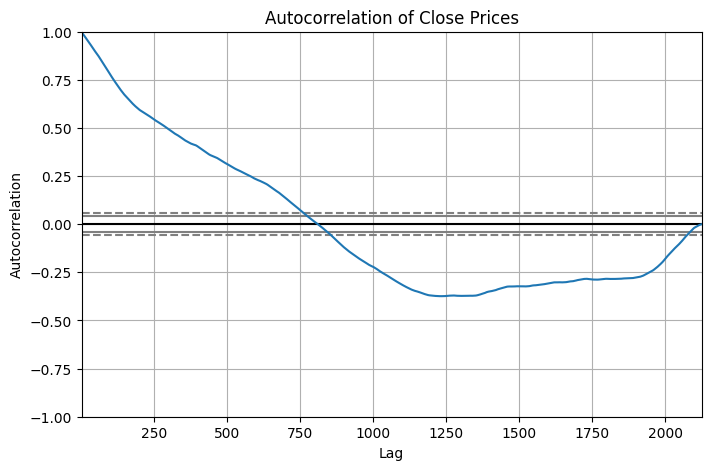

In [86]:
plt.figure(figsize=(8, 5))
autocorrelation_plot(categorized_df['Close'])
plt.title("Autocorrelation of Close Prices")
plt.show()